# Set up environment

In [22]:
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from collections import deque

In [23]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [24]:
class CustomLSTMExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 128):
        super().__init__(observation_space, features_dim)
        self.window_size = observation_space.shape[0]
        self.input_dim = observation_space.shape[1]
        self.lstm = nn.LSTM(input_size=self.input_dim, hidden_size=features_dim, batch_first=True)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(observations)
        last_step_out=lstm_out[:, -1, :]
        last_step_out=self.dropout(last_step_out)
        return last_step_out

# 数据准备

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [26]:
tech_daily = pd.read_csv(r"data\科技股票.csv")
tech_daily.set_index('date', inplace=True)
tech_daily.columns=['AAPL','GOOG','MSFT']
tech_daily

,AAPL,GOOG,MSFT
date,,,
2015-11-09,27.184789,35.998153,47.105569
2015-11-10,26.328007,36.168488,46.540233
2015-11-11,26.179197,36.520082,46.661997
2015-11-12,26.091265,36.312999,46.374980
2015-11-13,25.329180,35.606335,45.957501
...,...,...,...
2025-11-24,275.920000,318.470000,474.000000
2025-11-25,276.970000,323.640000,476.990000
2025-11-26,277.550000,320.280000,485.500000


In [27]:
debt=pd.read_csv(r"data\无风险.csv")
debt.set_index('date', inplace=True)
debt.columns=['US_debt']
debt

,US_debt
date,
2015-11-09,19.950578
2015-11-10,19.974528
2015-11-11,19.934611
2015-11-12,19.982512
2015-11-13,20.030412
...,...
2025-11-24,23.230000
2025-11-25,23.280000
2025-11-26,23.295000


In [28]:
tmp=pd.read_csv(r"data\指数和贵金属.csv")
tmp.columns=['date','SP500','Gold']
tmp.set_index('date', inplace=True)
tmp

,SP500,Gold
date,,
2015-11-09,2078.58,1090.7
2015-11-10,2081.72,1087.9
2015-11-11,2075.00,1084.2
2015-11-12,2045.97,1083.5
2015-11-13,2023.04,1081.3
...,...,...
2025-11-24,6705.12,4133.8
2025-11-25,6765.88,4126.3
2025-11-26,6812.61,4196.1


In [29]:
df=pd.merge(tech_daily,debt,how='left',on='date')
df=pd.merge(df,tmp,how='left',on='date')
df['date']=pd.to_datetime(df.index)
df.set_index('date', inplace=True)
df[df.isnull().values == True]

,AAPL,GOOG,MSFT,US_debt,SP500,Gold
date,,,,,,
2017-03-28,33.287503,40.767019,59.093436,20.711540,2358.57,NaN
2017-03-30,33.317596,41.292423,59.473574,20.694991,2368.06,NaN
2017-04-04,33.512043,41.444880,59.491676,20.802890,2360.16,NaN
2017-04-10,33.141667,40.956224,59.310658,20.811185,2357.16,NaN
2018-05-28,NaN,NaN,NaN,NaN,NaN,1297.5
...,...,...,...,...,...,...
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6


In [30]:
df['Cash']=1 
df

,AAPL,GOOG,MSFT,US_debt,SP500,Gold,Cash
date,,,,,,,
2015-11-09,27.184789,35.998153,47.105569,19.950578,2078.58,1090.7,1
2015-11-10,26.328007,36.168488,46.540233,19.974528,2081.72,1087.9,1
2015-11-11,26.179197,36.520082,46.661997,19.934611,2075.00,1084.2,1
2015-11-12,26.091265,36.312999,46.374980,19.982512,2045.97,1083.5,1
2015-11-13,25.329180,35.606335,45.957501,20.030412,2023.04,1081.3,1
...,...,...,...,...,...,...,...
2025-11-24,275.920000,318.470000,474.000000,23.230000,6705.12,4133.8,1
2025-11-25,276.970000,323.640000,476.990000,23.280000,6765.88,4126.3,1
2025-11-26,277.550000,320.280000,485.500000,23.295000,6812.61,4196.1,1


In [31]:
df.interpolate(method='time', inplace=True)
df.dropna(inplace=True)

In [32]:
from math import inf
import talib
import numpy as np
import pandas as pd
import gymnasium as gym
import torch
from collections import deque

In [ ]:
class PortfolioOptimizationEnv(gym.Env):
    def __init__(
        self, tickers, window_size, start_date, end_date, initial_balance, lambda_softmax, lambda_turnover, seed=None
    ):
        super().__init__()
        self.tickers = tickers
        self.window_size = window_size
        self.initial_balance = initial_balance
        self.lambda_softmax=lambda_softmax
        self.lambda_turnover=lambda_turnover

        self.raw_data, self.feature_data = self.get_data(tickers, start_date, end_date)
        self.n_features = self.feature_data.shape[1]

        self.action_space = gym.spaces.Box(low=0, high=1, shape=(len(tickers),))
        self.observation_space = gym.spaces.Box(
            low=-inf, high=inf, shape=(window_size, self.n_features)
        )

        self.return_window = deque(maxlen=window_size)
        self.last_action = np.ones(len(tickers)) / len(tickers)

        if seed is not None:
            np.random.seed(seed)
            self.action_space.seed(seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

    def get_data(self, tickers, start_date, end_date):
        data = df.copy()
        data = data.loc[start_date:end_date, tickers]
        if data.empty:
            raise ValueError(f"No data found for range {start_date} to {end_date}")
            
        raw_data = data.copy()

        returns = data.pct_change()
        feature_list=[returns]

        feature_data=pd.concat(feature_list, axis=1)
        feature_data=feature_data.dropna()
        raw_data=raw_data.reindex(feature_data.index).dropna()

        return raw_data, feature_data

    def reset(self, seed=None):
        self.balance = self.initial_balance
        self.current_step = self.window_size
        self.return_window.clear()
        self.last_action = np.ones(len(self.tickers)) / len(self.tickers)
        obs = self.feature_data.iloc[
            self.current_step - self.window_size : self.current_step
        ].values
        info = {"balance": self.balance}
        return obs, info

    def step(self, action):
        action = np.asarray(action).ravel()
        action = np.exp(action / self.lambda_softmax) 
        action = action / np.sum(action)

        if self.current_step >= len(self.raw_data):
            done = True
            obs = self.feature_data.iloc[
                self.current_step - self.window_size : self.current_step
            ].values
            return obs, 0, True, False, {"balance": self.balance}

        current_price = self.raw_data.iloc[self.current_step].values[: len(self.tickers)]
        prev_price = self.raw_data.iloc[self.current_step - 1].values[: len(self.tickers)]
        asset_returns = current_price / prev_price - 1
        self.return_window.append(asset_returns)

        portfolio_return = np.sum(asset_returns * action)
        
        turnover = np.sum(np.abs(action - self.last_action))
        transaction_cost = 0.0001 * turnover
        self.balance = self.balance * (1 + portfolio_return - transaction_cost)
        
        volatility = np.std(self.return_window) if len(self.return_window) > 10 else 0.01
        self.last_action = action

        variance = np.var(self.return_window) if len(self.return_window) > 10 else 0.0

        lambda_risk=0.5
        reward = portfolio_return - (lambda_risk * variance) - (self.lambda_turnover * turnover)

        self.current_step += 1
        done = self.current_step >= len(self.raw_data) - 1
        
        # Handle end of episode
        if done:
             obs = self.feature_data.iloc[
                self.current_step - self.window_size - 1 : self.current_step - 1
            ].values
        else:
            obs = self.feature_data.iloc[
                self.current_step - self.window_size : self.current_step
            ].values

        return obs, reward, bool(done), False, {"balance": self.balance, "weights": action}

In [34]:
tickers = df.columns.tolist()
window_size = 30
initial_balance = 10000
seed = 8

# Define Split Dates based on corrected dataframe
full_range = df.index
split_idx = int(len(full_range) * 0.6) # train test split
train_start_date = full_range[0]
train_end_date = full_range[split_idx]
test_start_date = full_range[split_idx + 1]
test_end_date = full_range[-1]

print(f"Train Period: {train_start_date.date()} to {train_end_date.date()}")
print(f"Test Period:  {test_start_date.date()} to {test_end_date.date()}")

Train Period: 2015-11-09 to 2021-12-09
Test Period:  2021-12-10 to 2025-11-28


# Training DRL agent

## SAC

In [35]:
from stable_baselines3.common.monitor import Monitor

In [ ]:
log_dir = "./sb3_logs"
os.makedirs(log_dir, exist_ok=True)

def make_env_for_period(start_date, end_date, monitor_file=None):
    def _init():
        env_ = PortfolioOptimizationEnv(
            tickers=tickers,
            window_size=window_size,
            start_date=start_date,
            end_date=end_date,
            initial_balance=initial_balance,
            lambda_turnover=0.001,
            lambda_softmax=0.25,
            seed=seed,
        )
        if monitor_file is not None:
            env_ = Monitor(env_, filename=monitor_file)
        return env_
    return _init

policy_kwargs = dict(
    features_extractor_class=CustomLSTMExtractor,
    features_extractor_kwargs=dict(features_dim=128),
    net_arch=[128, 64],
    optimizer_kwargs=dict(weight_decay=1e-5)
)

In [37]:
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [ ]:
monitor_path = os.path.join(log_dir, "monitor_train.csv")
vec_train_env = DummyVecEnv([make_env_for_period(train_start_date, train_end_date, monitor_file=monitor_path)])
vec_train_env = VecNormalize(vec_train_env, norm_obs=True, norm_reward=False, clip_obs=10.0)

model = SAC(
    "MlpPolicy",
    vec_train_env,
    verbose=1,
    device=device,
    policy_kwargs=policy_kwargs,
    learning_rate=1e-4,
    batch_size=256,
    buffer_size=200_000,
    gamma=0.99,
    tau=0.005,
    ent_coef=0.005,
    train_freq=(256, "step"),
    gradient_steps=-1,
)

print("Starting training...")
model.learn(total_timesteps=100000) # test
print("Training finished.")

model_path = os.path.join(log_dir, "sac_train.zip")
vecnorm_path = os.path.join(log_dir, "sac_vecnorm.pkl")
model.save(model_path)
vec_train_env.save(vecnorm_path)
print(f"Saved model to {model_path}")

Using cuda device
Starting training...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.48e+03 |
|    ep_rew_mean     | 217      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 35       |
|    time_elapsed    | 166      |
|    total_timesteps | 5936     |
| train/             |          |
|    actor_loss      | -4.61    |
|    critic_loss     | 0.0773   |
|    ent_coef        | 0.005    |
|    learning_rate   | 0.0003   |
|    n_updates       | 5888     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.48e+03 |
|    ep_rew_mean     | 304      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 35       |
|    time_elapsed    | 331      |
|    total_timesteps | 11872    |
| train/             |          |
|    actor_loss      | -7.96    |
|    critic_loss     | 0.0698   |
|    ent_

In [ ]:
print("Starting backtest...")
test_env_raw = DummyVecEnv([make_env_for_period(test_start_date, test_end_date, monitor_file=None)])
test_env = VecNormalize.load(vecnorm_path, test_env_raw)
test_env.training = False
test_env.norm_reward = False

obs = test_env.reset()
dones = [False]
balances = []
dates = []
weights_history = []

base_env = test_env.envs[0]
while hasattr(base_env, "env"):
    base_env = base_env.env

# Initial balance
balances.append(initial_balance)
start_idx = base_env.raw_data.index.get_loc(base_env.raw_data.index[base_env.window_size])
dates.append(base_env.raw_data.index[start_idx])

while not dones[0]:
    action, _ = model.predict(obs, deterministic=True)
    # Apply softmax to get actual weights
    raw_action = action[0]
    lambda_softmax = 0.25
    exp_action = np.exp((raw_action - np.max(raw_action)) / lambda_softmax)
    weights = exp_action / np.sum(exp_action)
    weights_history.append(weights)  # Store normalized weights
    obs, reward, dones, infos = test_env.step(action)
    
    if not dones[0]:
        balances.append(float(infos[0]["balance"]))
        # Get date for the current step
        cur_idx = base_env.current_step
        if cur_idx < len(base_env.raw_data):
            dates.append(base_env.raw_data.index[cur_idx])

Starting backtest...


In [48]:
import matplotlib.pyplot as plt

----------------------------------------
Performance Metrics (2022-03-10 to 2025-11-27)
----------------------------------------
Final Balance:    16025.05 (Initial: 10000.00)
Total Growth:     1.6025x
CAGR (Ann. Ret):  13.52%
Ann. Volatility:  22.49%
Sharpe Ratio:     0.6013
Sortino Ratio:    0.8133
Max Drawdown:     -27.47%
Calmar Ratio:     0.4922
----------------------------------------
Performance plot saved to ./sb3_logs\backtest_result.png


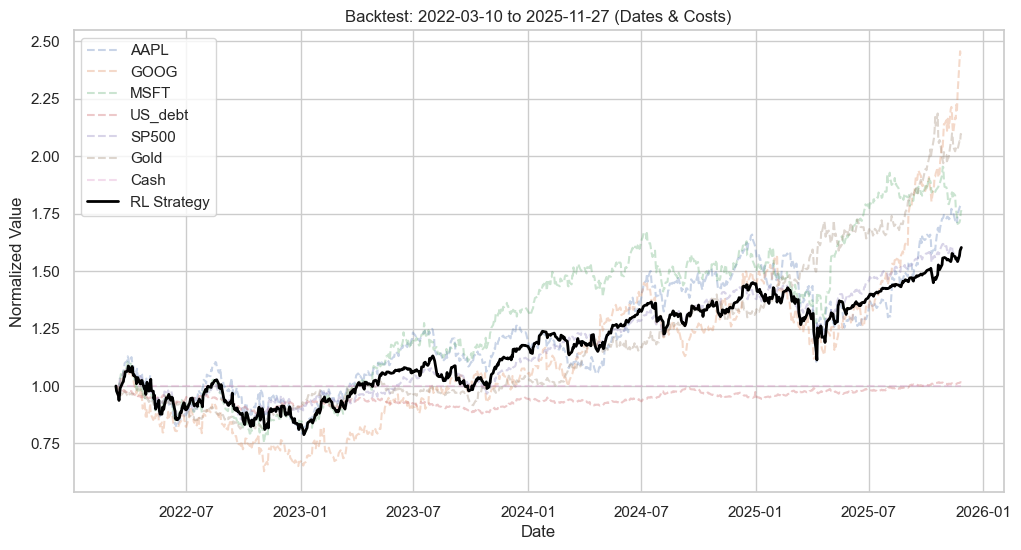

In [ ]:
balances_arr = np.array(balances)
if len(balances_arr) > 0:
    # 1. Basic Metrics
    total_growth = balances_arr[-1] / balances_arr[0]
    
    # 2. Time-based Metrics
    # Calculate duration in years
    start_date = pd.to_datetime(dates[0])
    end_date = pd.to_datetime(dates[-1])
    duration_days = (end_date - start_date).days
    years = duration_days / 365.25 if duration_days > 0 else 0
    
    # 3. Returns Analysis
    # Convert balances to a Series to calculate daily returns
    balance_series = pd.Series(balances_arr, index=dates)
    daily_returns = balance_series.pct_change().dropna()
    
    # CAGR (Compound Annual Growth Rate)
    if years > 0:
        cagr = (total_growth) ** (1 / years) - 1
    else:
        cagr = 0
        
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = cagr / ann_vol if ann_vol != 0 else 0
    
    # Sortino Ratio (Downside Deviation)
    downside_returns = daily_returns[daily_returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    # Max Drawdown
    cumulative_max = np.maximum.accumulate(balances_arr)
    drawdowns = (balances_arr - cumulative_max) / cumulative_max
    max_drawdown = np.min(drawdowns)
    
    # Calmar Ratio
    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else 0

    print("-" * 40)
    print(f"Performance Metrics ({start_date.date()} to {end_date.date()})")
    print("-" * 40)
    print(f"Final Balance:    {balances_arr[-1]:.2f} (Initial: {balances_arr[0]:.2f})")
    print(f"Total Growth:     {total_growth:.4f}x")
    print(f"CAGR (Ann. Ret):  {cagr:.2%}")
    print(f"Ann. Volatility:  {ann_vol:.2%}")
    print(f"Sharpe Ratio:     {sharpe:.4f}")
    print(f"Sortino Ratio:    {sortino:.4f}")
    print(f"Max Drawdown:     {max_drawdown:.2%}")
    print(f"Calmar Ratio:     {calmar:.4f}")
    print("-" * 40)

    asset_cols = tickers
    prices = df.loc[dates, asset_cols].copy()
    norm_prices = prices / prices.iloc[0]
    
    norm_strategy = balances_arr / balances_arr[0]

    strategy_df = pd.DataFrame({'date': pd.to_datetime(dates), 'value': norm_strategy})
    strategy_df = strategy_df.sort_values('date').drop_duplicates('date')

    # Plot 1: Performance
    plt.figure(figsize=(12, 6))
    for col in asset_cols:
        plt.plot(norm_prices.index, norm_prices[col], label=col, alpha=0.3, linestyle='--')
        
    plt.plot(strategy_df['date'], strategy_df['value'], label="RL Strategy", linewidth=2, color='black')
    
    plt.title(f"Backtest: {start_date.date()} to {end_date.date()} (Dates & Costs)")
    plt.xlabel("Date")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, "backtest_result.png"))
    print(f"Performance plot saved to {os.path.join(log_dir, 'backtest_result.png')}")

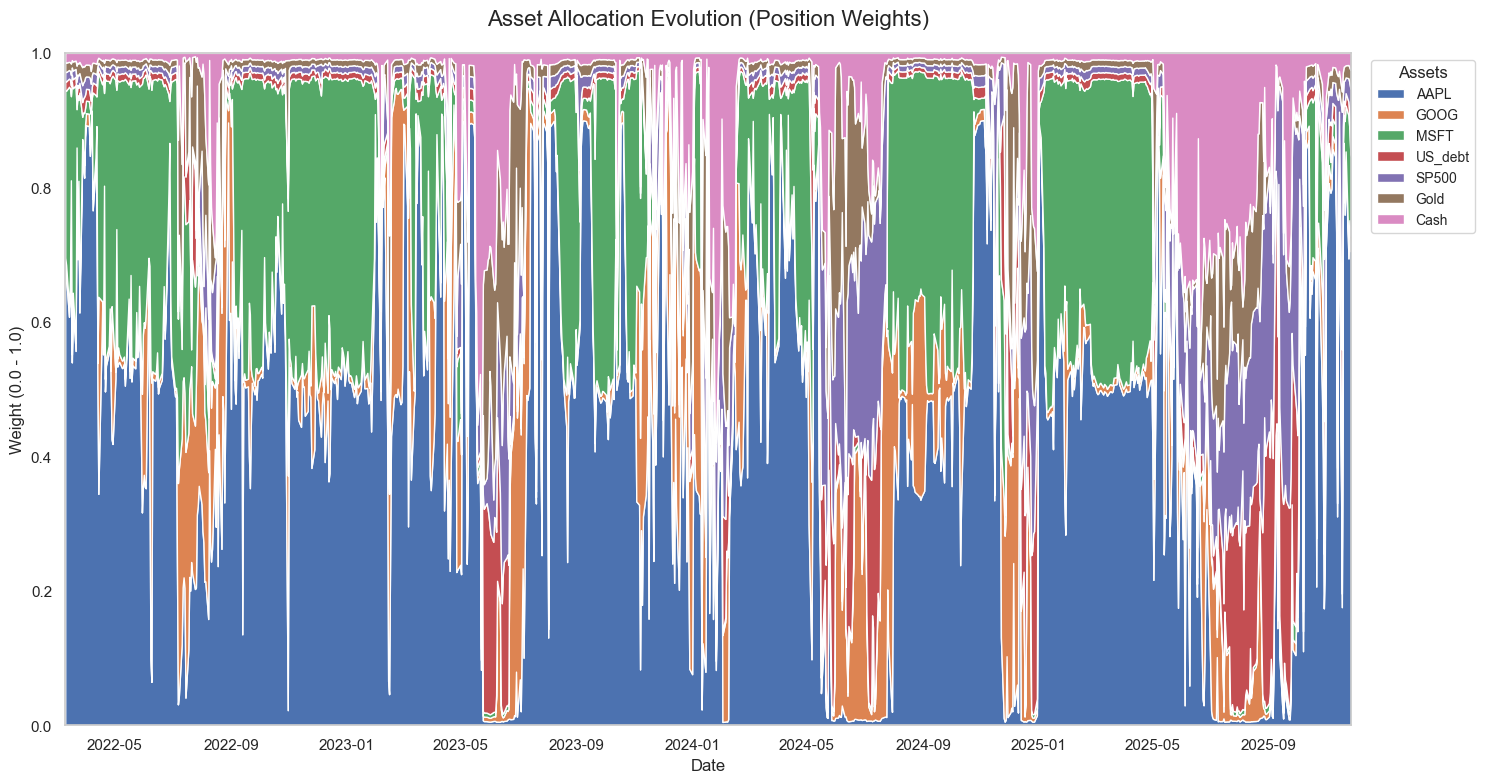


=== Position Statistics ===
Average Position:
AAPL       0.436785
MSFT       0.197666
GOOG       0.106570
Cash       0.074422
SP500      0.072006
Gold       0.059060
US_debt    0.053491

Max Single Position: 90.00% (AAPL)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

if len(weights_history) > 0:
    df_weights = pd.DataFrame(weights_history, columns=tickers)

    if "dates" in locals() and len(dates) >= len(df_weights):
        df_weights.index = dates[: len(df_weights)]

    plt.figure(figsize=(15, 8))

    plt.stackplot(df_weights.index, df_weights.T, labels=df_weights.columns)

    plt.title("Asset Allocation Evolution (Position Weights)", fontsize=16, pad=20)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Weight (0.0 - 1.0)", fontsize=12)
    plt.ylim(0, 1.0)
    plt.margins(x=0)

    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=10, title="Assets")

    plt.tight_layout()
    plt.show()
    
    print("\n=== Position Statistics ===")
    print(
        f"Average Position:\n{df_weights.mean().sort_values(ascending=False).to_string()}"
    )
    print(
        f"\nMax Single Position: {df_weights.max().max():.2%} ({df_weights.max().idxmax()})"
    )

else:
    print("Error: No weights history found. Please run the backtest loop first.")

# 修改部分

添加了科技股票、国债、标普500和黄金等数据作为环境输入特征

## 收益严重偏大，进行修改：

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10297.47
End wealth:    23731074.08
Total growth:  2304.553868
CAGR:          804.485651%
Ann. Return (geom from equity): 804.485651%
Ann. Vol:      22.710210%
Sharpe (rf=0): 9.8502
Max Drawdown:  -5.59%
Calmar:        143.9561

### 1、对vec_env进行了归一化处理

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10180.25
End wealth:    1013360.39
Total growth:  99.541782
CAGR:          270.067928%
Ann. Return (geom from equity): 270.067928%
Ann. Vol:      22.074986%
Sharpe (rf=0): 6.0514
Max Drawdown:  -8.50%
Calmar:        31.7818

### 2、调整奖励函数
用协方差矩阵估计组合波动
添加每次交易成本千一

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10055.45
End wealth:    54941.09
Total growth:  5.463811
CAGR:          62.092061%
Ann. Return (geom from equity): 62.092061%
Ann. Vol:      17.712724%
Sharpe (rf=0): 2.8174
Max Drawdown:  -11.18%
Calmar:        5.5563

### 3、更换为sac算法

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10145.52
End wealth:    22875.43
Total growth:  2.254731
CAGR:          26.016893%
Ann. Return (geom from equity): 26.016893%
Ann. Vol:      14.523819%
Sharpe (rf=0): 1.6653
Max Drawdown:  -12.48%
Calmar:        2.0840

删除了step函数中对动作的softmax处理

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10096.53
End wealth:    36203.07
Total growth:  3.585696
CAGR:          43.791829%
Ann. Return (geom from equity): 43.791829%
Ann. Vol:      12.005115%
Sharpe (rf=0): 3.0874
Max Drawdown:  -8.52%
Calmar:        5.1418

# 优化奖励函数权重

benchmark:

lambda_risk = 1
lambda_turnover = 0.01
reward = base_reward - lambda_risk * risk_penalty - lambda_turnover * cost

=== Portfolio Performance (deterministic rollout) ===
Periods per year (inferred): 252.00
Start wealth:  10164.10
End wealth:    39643.65
Total growth:  3.900359
CAGR:          47.273482%
Ann. Return (geom from equity): 47.273482%
Ann. Vol:      17.140595%
Sharpe (rf=0): 2.3455
Max Drawdown:  -13.67%
Calmar:        3.4585

# 加入lstm

终值资产:	1.74  (初始 1.00)
总增长倍数:	1.7411
年化收益:	15.51%
年化波动:	15.85%
Sharpe:		0.98

发现Sharpe指数反而变低，可能是由于：
1、训练步数不够，未收敛
2、特征中已包含滚动窗口统计量，可能导致模型过拟合
3、超参数未调优